# Phase 1

## Explode specification

In [ ]:
from pathlib import Path
import pandas as pd


def find_data_dir(start_path=None):
    """
    Find the project's Data/data directory by searching the current
    directory and each of its parent directories.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for folder_name in ("Data", "data"):
            candidate = directory / folder_name

            if candidate.is_dir():
                return candidate

    raise FileNotFoundError(
        f"Could not find a 'Data' or 'data' directory from: {start_path}"
    )


DATA_DIR = find_data_dir()

path = (
    DATA_DIR
    / "prompt_data"
    / "Phase1_prompts_spec_align.csv"
)

if not path.is_file():
    raise FileNotFoundError(
        f"Prompt-alignment file not found: {path}"
    )

df = pd.read_csv(path)

print(f"DataFrame loaded from {path}. Shape: {df.shape}")

# Only keep rows where a specification is provided.
df = (
    df[df["specification"] != "G1"]
    .reset_index(drop=True)
)

cols_to_keep = [
    "id",
    "Task",
    "specification",
    "prompt_text",
    "response_text",
    "before_g2_ac",
    "before_g2_constraints",
    "before_g3_constraints",
    "before_g3_frs",
    "before_g3_invariants",
    "before_g3_tie_breaking",
    "before_g3_exception",
    "before_g3_neg_req",
]

df = df[cols_to_keep]

df.head()

,id,Task,specification,prompt_text,response_text,before_g2_ac,before_g2_constraints,before_g3_constraints,before_g3_frs,before_g3_invariants,before_g3_tie_breaking,before_g3_exception,before_g3_neg_req
0,S0025,B,G2,help me develop this: system description: ”you...,1: ##: ##: stub file for the is allocation fe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S0025,B,G2,"""go through each block of code please, i cant ...","2: ""signature and type aliases python from ty...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S0026,B,G2,help me develop this: system description: ”you...,1: ## : ## : stub file for the is allocation ...,[{'ac_1': 'returns T when total demand is with...,[{'c_1': 'resources names as strings and case ...,NaN,NaN,NaN,NaN,NaN,NaN
3,S0027,B,G2,"""why am i gettingthis error file ""/cs/home/04/...","1: ""run this in your terminal: pip insll pyte...","[{'ac_1': 'Given user provides cpu:10, ram:32,...","[{'c_1': 'Resources must be non-negative.', 'c...",NaN,NaN,NaN,NaN,NaN,NaN
4,S0027,B,G2,"""this is my solution but there is a bug here a...","2: ""1 your docstring is in the wrong place (b...","[{'ac_1': 'Given user provides cpu:10, ram:32,...","[{'c_1': 'Resources must be non-negative.', 'c...",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import ast
import numpy as np



def is_empty_value(value):
    """
    Defines what counts as empty.
    """
    if value is None:
        return True

    if isinstance(value, float) and np.isnan(value):
        return True

    if isinstance(value, str) and value.strip() == "":
        return True

    return False


def try_convert_string_to_python_object(value):
    """
    Converts string representations of lists/dicts into actual Python objects.
    Example:
    "[{'ac_1': '', 'ac_2': 'text'}]" -> [{'ac_1': '', 'ac_2': 'text'}]
    """
    if not isinstance(value, str):
        return value

    value_stripped = value.strip()

    if (
        (value_stripped.startswith("[") and value_stripped.endswith("]"))
        or
        (value_stripped.startswith("{") and value_stripped.endswith("}"))
    ):
        try:
            return ast.literal_eval(value_stripped)
        except (ValueError, SyntaxError):
            return value

    return value


def clean_value(value):
    """
    Removes empty dictionary keys from lists/dicts.
    If the cleaned list/dict becomes empty, returns None.
    """

    value = try_convert_string_to_python_object(value)

    if pd.isna(value) if not isinstance(value, (list, dict)) else False:
        return None

    # Case 1: list, usually like [{'ac_1': '', 'ac_2': ''}]
    if isinstance(value, list):
        cleaned_list = []

        for item in value:
            if isinstance(item, dict):
                cleaned_dict = {
                    key: val
                    for key, val in item.items()
                    if not is_empty_value(val)
                }

                if cleaned_dict:
                    cleaned_list.append(cleaned_dict)

            elif not is_empty_value(item):
                cleaned_list.append(item)

        return cleaned_list if cleaned_list else None

    # Case 2: single dictionary
    if isinstance(value, dict):
        cleaned_dict = {
            key: val
            for key, val in value.items()
            if not is_empty_value(val)
        }

        return cleaned_dict if cleaned_dict else None

    return value

print(f"df shape before cleaning: {df.shape}")
# Apply to every cell in the dataframe
df = df.map(clean_value)
print(f"df shape after cleaning: {df.shape}")
# Save cleaned dataframe
df.to_csv(path, index=False)

print(f"Cleaned dataframe saved to: {path}")

df shape before cleaning: (226, 13)
df shape after cleaning: (226, 13)


In [6]:
df.head()

,id,Task,specification,prompt_text,response_text,before_g2_ac,before_g2_constraints,before_g3_constraints,before_g3_frs,before_g3_invariants,before_g3_tie_breaking,before_g3_exception,before_g3_neg_req
0,S0025,B,G2,help me develop this: system description: ”you...,1: ##: ##: stub file for the is allocation fe...,None,None,None,None,None,None,None,None
1,S0025,B,G2,"""go through each block of code please, i cant ...","2: ""signature and type aliases python from ty...",None,None,None,None,None,None,None,None
2,S0026,B,G2,help me develop this: system description: ”you...,1: ## : ## : stub file for the is allocation ...,[{'ac_1': 'returns T when total demand is with...,[{'c_1': 'resources names as strings and case ...,None,None,None,None,None,None
3,S0027,B,G2,"""why am i gettingthis error file ""/cs/home/04/...","1: ""run this in your terminal: pip insll pyte...","[{'ac_1': 'Given user provides cpu:10, ram:32,...","[{'c_1': 'Resources must be non-negative.', 'c...",None,None,None,None,None,None
4,S0027,B,G2,"""this is my solution but there is a bug here a...","2: ""1 your docstring is in the wrong place (b...","[{'ac_1': 'Given user provides cpu:10, ram:32,...","[{'c_1': 'Resources must be non-negative.', 'c...",None,None,None,None,None,None


## Labelling

For each participant and phase, we first checked (i)
how many prompts explicitly referred to the specification, then
followed by whether the transcript: (ii) carried constraints
from the specification into prompts, (iii) carried edge cases
from the specification into prompts, (iv) asked the LLM to
preserve invariants, (v) asked the LLM to update or generate
tests based on the specification, and (vi) omitted important
specification elements during prompting.

In [7]:
from pathlib import Path
import os
import time
import json
import re
import ast
import pandas as pd
from tqdm import tqdm
from groq import Groq

# =========================
# Helper functions
# =========================

def safe_cell(value):
    """
    Converts NaN to empty string.
    Converts stringified lists/dicts to Python objects when possible.
    Keeps regular strings as-is.
    """
    if pd.isna(value):
        return ""

    if isinstance(value, str):
        stripped = value.strip()

        if (
            (stripped.startswith("[") and stripped.endswith("]"))
            or (stripped.startswith("{") and stripped.endswith("}"))
        ):
            try:
                return ast.literal_eval(stripped)
            except Exception:
                return value

    return value


def stringify_spec_part(value):
    """
    Converts spec fields into readable text for the LLM.
    Handles strings, lists, and dictionaries.
    """
    value = safe_cell(value)

    if value == "":
        return ""

    if isinstance(value, (list, dict)):
        return json.dumps(value, ensure_ascii=False)

    return str(value)


def get_G2_spec(row):
    """
    G2-level specification.
    Adjust columns here if your G2 specification contains more fields.
    """
    spec_parts = {
        "goal": row.get("before_g2_goal", ""),
        "input": row.get("before_g2_input", ""),
        "output": row.get("before_g2_output", ""),
        "acceptance_criteria": row.get("before_g2_ac", ""),
        "constraints": row.get("before_g2_constraints", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_G3_spec(row):
    """
    G3-level specification.
    """
    spec_parts = {
        "functional_requirements": row.get("before_g3_frs", ""),
        "constraints": row.get("before_g3_constraints", ""),
        "invariants": row.get("before_g3_invariants", ""),
        "tie_breaking": row.get("before_g3_tie_breaking", ""),
        "exceptions": row.get("before_g3_exception", ""),
        "negative_requirements": row.get("before_g3_neg_req", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_specification_text(row):
    if row.get("specification", "") == "G2":
        return get_G2_spec(row)

    if row.get("specification", "") == "G3":
        return get_G3_spec(row)

    return ""


def get_labeling_prompt(row):
    specification_level = row.get("specification", "")
    specification_text = get_specification_text(row)
    prompt_text = stringify_spec_part(row.get("prompt_text", ""))

    return f"""
You are an expert software requirements and LLM-prompting researcher.You are given:
1. A software specification.
2. A developer's prompt or transcript of prompts to an LLM.
Your task is to label how the developer used the specification while prompting the LLM.
Definitions:
A. explicitly_referred_to_specification
- true if the developer explicitly refers to any parts of their specification.
- false if the developer only asks general coding/debugging questions without referencing specification content.
B. carried_constraints_from_spec
- true if the developer includes, paraphrases, or enforces constraints from the specification in the prompt. in specification constrainsts are labeled as C_1, c_2, etc.
C. carried_edge_cases_from_spec
- true if the developer includes edge cases, exception cases, corner cases, invalid inputs, boundary cases, tie cases, negative cases, or special cases from the specification.
- For G3, exceptions, tie-breaking, and negative requirements may count as edge/special cases when carried into the prompt.
D. asked_to_preserve_invariants
- true if the developer asks the LLM to preserve, maintain, not break, enforce, or respect invariants.
- Also true if the prompt mentions invariant-like properties that must always remain true.
E. asked_to_update_or_generate_tests_based_on_spec
- true if the developer asks the LLM to create, update, fix, extend, or check tests using the specification, requirements, acceptance criteria, constraints, invariants, or edge cases.
- false if the prompt only asks for code or test without any specification reference.
F. omitted_important_spec_elements
- true if the developer's prompt uses the specification only partially and omits important relevant specification elements that should have been included for the requested task.
- false if the prompt sufficiently carries the relevant specification elements for the task, or if the prompt does not attempt to use the specification at all.
- Be conservative: mark true only when important omissions are clear from comparing the specification and the prompt.

For each label, provide:
- a boolean value
- a short evidence quote or paraphrase from the developer prompt
- a brief reason

Return ONLY valid JSON using exactly this schema:

{{
  "explicitly_referred_to_specification": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "carried_constraints_from_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "carried_edge_cases_from_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "asked_to_preserve_invariants": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "asked_to_update_or_generate_tests_based_on_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "omitted_important_spec_elements": {{
    "label": false,
    "evidence": "",
    "reason": ""
  }}
}}

Specification:
\"\"\"
{specification_text}
\"\"\"

Developer prompt/transcript:
\"\"\"
{prompt_text}
\"\"\"
"""


def extract_json(text):
    """
    Robustly extracts JSON even if the model accidentally adds text.
    """
    if text is None:
        raise ValueError("Empty response from model")

    text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in response: {text}")

    return json.loads(match.group(0))


def get_nested_label(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("label", None)
    return None


def get_nested_reason(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("reason", "")
    return ""


def get_nested_evidence(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("evidence", "")
    return ""


In [ ]:
api_keys = [
   # list of API keys for Groq, OpenAI, or other LLM providers
]

models = [
    # list of model names to try, e.g., "groq/compound", "openai/gpt-oss-20b"
    ## we used openai/gpt-oss-120b
]


for idx, row in df.iterrows():
        print(f"\nWorking on {row['id']}: {idx} / {len(df)}")
        if not (pd.isna(row["spec_label_raw_json"]) or row["spec_label_raw_json"] == ""):
                continue
    
        prompt = get_labeling_prompt(row)
        # print(prompt)
        success = False

        for model in models:
            print(f"\nTrying model: {model}")
            for api_key_idx, api_key in enumerate(api_keys, start=1):
                # print(f"Trying API key {api_key_idx} / {len(api_keys)} with model {model}")
                try:
                    client = Groq(api_key=api_key)
                    response = client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model,
                        temperature=0
                    )
                    result = response.choices[0].message.content
                    print(result)
                    df.loc[idx, "spec_label_raw_json"] = result
                    df.to_csv(path, index=False)
                    success = True
                    time.sleep(2)
                    break

                except Exception as e:
                    print(
                        f"Error with model {model}, API key {api_key_idx}: {e}. "
                        f"Trying next API key or model."
                    )
                    time.sleep(2)
            if success:
                break
        if not success:
            print(
                f"All models and API keys failed for participant "
                f"{row['id']}, row {idx}. Leaving Semantic_validity empty."
            )
            time.sleep(100)


Working on S0025: 0 / 226

Working on S0025: 1 / 226

Working on S0026: 2 / 226

Working on S0027: 3 / 226

Working on S0027: 4 / 226

Working on S0027: 5 / 226

Working on S0027: 6 / 226

Working on S0028: 7 / 226

Working on S0028: 8 / 226

Working on S0028: 9 / 226

Working on S0028: 10 / 226

Working on S0028: 11 / 226

Working on S0029: 12 / 226

Working on S0029: 13 / 226

Working on S0029: 14 / 226

Working on S0029: 15 / 226

Working on S0029: 16 / 226

Working on S0029: 17 / 226

Working on S0030: 18 / 226

Working on S0030: 19 / 226

Working on S0030: 20 / 226

Working on S0030: 21 / 226

Working on S0030: 22 / 226

Working on S0031: 23 / 226

Working on S0031: 24 / 226

Working on S0031: 25 / 226

Working on S0031: 26 / 226

Working on S0031: 27 / 226

Working on S0031: 28 / 226

Working on S0031: 29 / 226

Working on S0032: 30 / 226

Working on S0032: 31 / 226

Working on S0032: 32 / 226

Working on S0032: 33 / 226

Working on S0032: 34 / 226

Working on S0033: 35 / 226

W

# Phase 2

## Explode specification

In [ ]:
from pathlib import Path
import pandas as pd


def find_data_dir(start_path=None):
    """
    Find the project's Data/data directory by searching the current
    directory and its parent directories.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for folder_name in ("Data", "data"):
            candidate = directory / folder_name

            if candidate.is_dir():
                return candidate

    raise FileNotFoundError(
        f"Could not find a 'Data' or 'data' directory from: {start_path}"
    )


DATA_DIR = find_data_dir()

path = (
    DATA_DIR
    / "prompt_data"
    / "Phase2_prompts_spec_align.csv"
)

if not path.is_file():
    raise FileNotFoundError(
        f"Prompt-alignment file not found: {path}"
    )

df = pd.read_csv(path)

print(f"DataFrame loaded from {path}. Shape: {df.shape}")

# Only keep rows where a specification is provided.
df = (
    df[df["specification"] != "G1"]
    .reset_index(drop=True)
)

cols_to_keep = [
    "id",
    "Task",
    "specification",
    "prompt_text",
    "response_text",
    "after_g2_ac",
    "after_g2_constraints",
    "after_g3_constraints",
    "after_g3_fr",
    "afterg3_invariants",
    "after_g3_tb",
    "after_g3_exception",
    "after_g3_neg",
]

df = df[cols_to_keep]

df.head()

,id,Task,specification,prompt_text,response_text,after_g2_ac,after_g2_constraints,after_g3_constraints,after_g3_fr,afterg3_invariants,after_g3_tb,after_g3_exception,after_g3_neg
0,S0025,B,G2,help me update this code for this new requriem...,"1: from typing import dict, list, union impor...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN
1,S0025,B,G2,"""give me an accepnce criterion that would be c...","2: ""remaining unallocated resource (new requi...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN
2,S0025,B,G2,"""explain edge cases for me based on which i ca...","3: ""here are strong edge cases you can write ...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN
3,S0026,B,G2,help me update this code for this new requriem...,"1: from typing import dict, list, union impor...",[{'ac_1': 'schedule (capacity 10) valid demand...,[{'c_1': 'at least one resource must have rema...,NaN,NaN,NaN,NaN,NaN,NaN
4,S0026,B,G2,"""does my curent solution alredy handel the new...","2: ""based on the description of the original ...",[{'ac_1': 'schedule (capacity 10) valid demand...,[{'c_1': 'at least one resource must have rema...,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import ast
import numpy as np


def is_empty_value(value):
    """
    Defines what counts as empty.
    """
    if value is None:
        return True

    if isinstance(value, float) and np.isnan(value):
        return True

    if isinstance(value, str) and value.strip() == "":
        return True

    return False


def try_convert_string_to_python_object(value):
    """
    Converts string representations of lists/dicts into actual Python objects.
    Example:
    "[{'ac_1': '', 'ac_2': 'text'}]" -> [{'ac_1': '', 'ac_2': 'text'}]
    """
    if not isinstance(value, str):
        return value

    value_stripped = value.strip()

    if (
        (value_stripped.startswith("[") and value_stripped.endswith("]"))
        or
        (value_stripped.startswith("{") and value_stripped.endswith("}"))
    ):
        try:
            return ast.literal_eval(value_stripped)
        except (ValueError, SyntaxError):
            return value

    return value


def clean_value(value):
    """
    Removes empty dictionary keys from lists/dicts.
    If the cleaned list/dict becomes empty, returns None.
    """

    value = try_convert_string_to_python_object(value)

    if pd.isna(value) if not isinstance(value, (list, dict)) else False:
        return None

    # Case 1: list, usually like [{'ac_1': '', 'ac_2': ''}]
    if isinstance(value, list):
        cleaned_list = []

        for item in value:
            if isinstance(item, dict):
                cleaned_dict = {
                    key: val
                    for key, val in item.items()
                    if not is_empty_value(val)
                }

                if cleaned_dict:
                    cleaned_list.append(cleaned_dict)

            elif not is_empty_value(item):
                cleaned_list.append(item)

        return cleaned_list if cleaned_list else None

    # Case 2: single dictionary
    if isinstance(value, dict):
        cleaned_dict = {
            key: val
            for key, val in value.items()
            if not is_empty_value(val)
        }

        return cleaned_dict if cleaned_dict else None

    return value

print(f"df shape before cleaning: {df.shape}")
# Apply to every cell in the dataframe
df = df.map(clean_value)
print(f"df shape after cleaning: {df.shape}")
# Save cleaned dataframe
df.to_csv(path, index=False)

print(f"Cleaned dataframe saved to: {path}")

## Labelling

In [27]:
from pathlib import Path
import os
import time
import json
import re
import ast
import pandas as pd
from tqdm import tqdm
from groq import Groq

# =========================
# Helper functions
# =========================

def safe_cell(value):
    """
    Converts NaN to empty string.
    Converts stringified lists/dicts to Python objects when possible.
    Keeps regular strings as-is.
    """
    if pd.isna(value):
        return ""

    if isinstance(value, str):
        stripped = value.strip()

        if (
            (stripped.startswith("[") and stripped.endswith("]"))
            or (stripped.startswith("{") and stripped.endswith("}"))
        ):
            try:
                return ast.literal_eval(stripped)
            except Exception:
                return value

    return value


def stringify_spec_part(value):
    """
    Converts spec fields into readable text for the LLM.
    Handles strings, lists, and dictionaries.
    """
    value = safe_cell(value)

    if value == "":
        return ""

    if isinstance(value, (list, dict)):
        return json.dumps(value, ensure_ascii=False)

    return str(value)


def get_G2_spec(row):
    """
    G2-level specification.
    Adjust columns here if your G2 specification contains more fields.
    """
    spec_parts = {
        "acceptance_criteria": row.get("after_g2_ac", ""),
        "constraints": row.get("after_g2_constraints", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )

def get_G3_spec(row):
    """
    G3-level specification.
    """
    spec_parts = {
        "functional_requirements": row.get("after_g3_fr", ""),
        "constraints": row.get("after_g3_constraints", ""),
        "invariants": row.get("afterg3_invariants", ""),
        "tie_breaking": row.get("after_g3_tb", ""),
        "exceptions": row.get("after_g3_exception", ""),
        "negative_requirements": row.get("after_g3_neg", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_specification_text(row):
    if row.get("specification", "") == "G2":
        return get_G2_spec(row)

    if row.get("specification", "") == "G3":
        return get_G3_spec(row)

    return ""


def get_labeling_prompt(row):
    specification_level = row.get("specification", "")
    specification_text = get_specification_text(row)
    prompt_text = stringify_spec_part(row.get("prompt_text", ""))

    return f"""
You are an expert software requirements and LLM-prompting researcher.You are given:
1. A software specification.
2. A developer's prompt or transcript of prompts to an LLM.
Your task is to label how the developer used the specification while prompting the LLM.
Definitions:
A. explicitly_referred_to_specification
- true if the developer explicitly refers to any parts of their specification.
- false if the developer only asks general coding/debugging questions without referencing specification content.
B. carried_constraints_from_spec
- true if the developer includes, paraphrases, or enforces constraints from the specification in the prompt. in specification constrainsts are labeled as C_1, c_2, etc.
C. carried_edge_cases_from_spec
- true if the developer includes edge cases, exception cases, corner cases, invalid inputs, boundary cases, tie cases, negative cases, or special cases from the specification.
- For G3, exceptions, tie-breaking, and negative requirements may count as edge/special cases when carried into the prompt.
D. asked_to_preserve_invariants
- true if the developer asks the LLM to preserve, maintain, not break, enforce, or respect invariants.
- Also true if the prompt mentions invariant-like properties that must always remain true.
E. asked_to_update_or_generate_tests_based_on_spec
- true if the developer asks the LLM to create, update, fix, extend, or check tests using the specification, requirements, acceptance criteria, constraints, invariants, or edge cases.
- false if the prompt only asks for code or test without any specification reference.
F. omitted_important_spec_elements
- true if the developer's prompt uses the specification only partially and omits important relevant specification elements that should have been included for the requested task.
- false if the prompt sufficiently carries the relevant specification elements for the task, or if the prompt does not attempt to use the specification at all.
- Be conservative: mark true only when important omissions are clear from comparing the specification and the prompt.

For each label, provide:
- a boolean value
- a short evidence quote or paraphrase from the developer prompt
- a brief reason

Return ONLY valid JSON using exactly this schema:

{{
  "explicitly_referred_to_specification": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "carried_constraints_from_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "carried_edge_cases_from_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "asked_to_preserve_invariants": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "asked_to_update_or_generate_tests_based_on_spec": {{
    "label": True/False,
    "evidence": "",
    "reason": ""
  }},
  "omitted_important_spec_elements": {{
    "label": false,
    "evidence": "",
    "reason": ""
  }}
}}

Specification:
\"\"\"
{specification_text}
\"\"\"

Developer prompt/transcript:
\"\"\"
{prompt_text}
\"\"\"
"""


def extract_json(text):
    """
    Robustly extracts JSON even if the model accidentally adds text.
    """
    if text is None:
        raise ValueError("Empty response from model")

    text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in response: {text}")

    return json.loads(match.group(0))


def get_nested_label(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("label", None)
    return None


def get_nested_reason(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("reason", "")
    return ""


def get_nested_evidence(result, key):
    value = result.get(key, {})
    if isinstance(value, dict):
        return value.get("evidence", "")
    return ""


In [ ]:
api_keys = [
    # list of API keys for Groq, OpenAI, or other LLM providers
]

models = [
    # list of model names to try, e.g., "groq/compound", "openai/gpt-oss-20b"
    ## we used openai/gpt-oss-120b
]


for idx, row in df.iterrows():
        print(f"\nWorking on {row['id']}: {idx} / {len(df)}")
        if not (pd.isna(row["spec_label_raw_json"]) or row["spec_label_raw_json"] == ""):
                continue
    
        prompt = get_labeling_prompt(row)
        success = False

        for model in models:
            print(f"\nTrying model: {model}")
            for api_key_idx, api_key in enumerate(api_keys, start=1):
                try:
                    client = Groq(api_key=api_key)
                    response = client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model,
                        temperature=0
                    )
                    result = response.choices[0].message.content
                    print(result)
                    df.loc[idx, "spec_label_raw_json"] = result
            
                    df.to_csv(path, index=False)
                    success = True
                    time.sleep(2)
                    break

                except Exception as e:
                    time.sleep(2)

            if success:
                break
        if not success:
            print(
                f"All models and API keys failed for participant "
                f"{row['id']}, row {idx}. Leaving Semantic_validity empty."
            )
            time.sleep(100)

# Kappa

## Prepare phase 1 csv for manual labelling

In [ ]:
import pandas as pd
import json
import re

path = "Phase1_prompts_spec_align.csv" ## please adjust this path to one in Data
df = pd.read_csv(path)

def parse_json_cell(x):
    if pd.isna(x):
        return None

    x = str(x).strip()

    # Remove markdown fences like ```json ... ```
    x = re.sub(r"^\s*```(?:json)?\s*", "", x, flags=re.IGNORECASE)
    x = re.sub(r"\s*```\s*$", "", x)

    return json.loads(x)

# Parse JSON strings into dictionaries
df["spec_label_raw_json"] = df["spec_label_raw_json"].apply(parse_json_cell)

# Expand each dict key into its own column
expanded = pd.json_normalize(df["spec_label_raw_json"])

# Optional: add prefix so new columns are easy to identify
expanded = expanded.add_prefix("spec_label_")

# Combine with original dataframe
df = pd.concat(
    [df.drop(columns=["spec_label_raw_json"]), expanded],
    axis=1
)
cols_to_drop =['spec_label_explicitly_referred_to_specification.evidence',
       'spec_label_explicitly_referred_to_specification.reason',
       'spec_label_carried_constraints_from_spec.evidence',
       'spec_label_carried_constraints_from_spec.reason',
       'spec_label_carried_edge_cases_from_spec.evidence',
       'spec_label_carried_edge_cases_from_spec.reason',
       'spec_label_asked_to_preserve_invariants.evidence',
       'spec_label_asked_to_preserve_invariants.reason',
       'spec_label_asked_to_update_or_generate_tests_based_on_spec.evidence',
       'spec_label_asked_to_update_or_generate_tests_based_on_spec.reason',
       'spec_label_omitted_important_spec_elements.evidence',
       'spec_label_omitted_important_spec_elements.reason']
df = df.drop(columns=cols_to_drop)
print(df.columns)
df.to_csv(path, index=False )
df.head()

In [25]:
from pathlib import Path
import os
import time
import json
import re
import ast
import pandas as pd
from tqdm import tqdm
from groq import Groq

# =========================
# Helper functions
# =========================

def safe_cell(value):
    """
    Converts NaN to empty string.
    Converts stringified lists/dicts to Python objects when possible.
    Keeps regular strings as-is.
    """
    if pd.isna(value):
        return ""

    if isinstance(value, str):
        stripped = value.strip()

        if (
            (stripped.startswith("[") and stripped.endswith("]"))
            or (stripped.startswith("{") and stripped.endswith("}"))
        ):
            try:
                return ast.literal_eval(stripped)
            except Exception:
                return value

    return value


def stringify_spec_part(value):
    """
    Converts spec fields into readable text for the LLM.
    Handles strings, lists, and dictionaries.
    """
    value = safe_cell(value)

    if value == "":
        return ""

    if isinstance(value, (list, dict)):
        return json.dumps(value, ensure_ascii=False)

    return str(value)


def get_G2_spec(row):
    """
    G2-level specification.
    Adjust columns here if your G2 specification contains more fields.
    """
    spec_parts = {
        "goal": row.get("before_g2_goal", ""),
        "input": row.get("before_g2_input", ""),
        "output": row.get("before_g2_output", ""),
        "acceptance_criteria": row.get("before_g2_ac", ""),
        "constraints": row.get("before_g2_constraints", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_G3_spec(row):
    """
    G3-level specification.
    """
    spec_parts = {
        "functional_requirements": row.get("before_g3_frs", ""),
        "constraints": row.get("before_g3_constraints", ""),
        "invariants": row.get("before_g3_invariants", ""),
        "tie_breaking": row.get("before_g3_tie_breaking", ""),
        "exceptions": row.get("before_g3_exception", ""),
        "negative_requirements": row.get("before_g3_neg_req", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_specification_text(row):
    if row.get("specification", "") == "G2":
        return get_G2_spec(row)

    if row.get("specification", "") == "G3":
        return get_G3_spec(row)

    return ""


In [ ]:
## sample ~20%
import pandas as pd

path = "Phase1_prompts_spec_align.csv" ## pass the path to the cleaned Phase1_prompts_spec_align.csv file
df = pd.read_csv(path)
print(df.shape)
df.head()

# Sample 8 submissions (10%)
sample_ids = df['id'].drop_duplicates().sample(n=8, random_state=42)

# # Get all rows corresponding to those review_ids
sample_df = df[df['id'].isin(sample_ids)]
sample_df["explicitly_referred_to_spec_man"] = ""
sample_df["carried_constraints_from_spec_man"] = ""
sample_df["carried_edge_cases_from_spec_man"] = ""
sample_df["asked_to_preserve_invariants_man"] = ""
sample_df["asked_to_update_or_generate_tests_based_on_spec_man"] = ""
sample_df["omitted_important_spec_elements_man"] = ""
cols_to_keep = ['id', 'Task', 'specification', 'prompt_text', 'response_text',
       'before_g2_ac', 'before_g2_constraints', 'before_g3_constraints',
       'before_g3_frs', 'before_g3_invariants', 'before_g3_tie_breaking',
       'before_g3_exception', 'before_g3_neg_req',
       'spec_label_explicitly_referred_to_specification.label',
       "explicitly_referred_to_spec_man", 
       'spec_label_carried_constraints_from_spec.label',
         "carried_constraints_from_spec_man",
       'spec_label_carried_edge_cases_from_spec.label',
            "carried_edge_cases_from_spec_man",
       'spec_label_asked_to_preserve_invariants.label',
        "asked_to_preserve_invariants_man",
       'spec_label_asked_to_update_or_generate_tests_based_on_spec.label',
        "asked_to_update_or_generate_tests_based_on_spec_man",
       'spec_label_omitted_important_spec_elements.label', 
        "omitted_important_spec_elements_man"]
sample_df = sample_df[cols_to_keep]
print(len(sample_df))


sample_df["prompt"] = ""
for idx, row in sample_df.iterrows():
    specification = get_specification_text(row)
    interaction = row["prompt_text"]
    prompt = f"""Specification: {specification} \n  Interaction: {interaction}"""
    sample_df.at[idx, "prompt"] = prompt
    
sample_df.to_csv("RQ1_Phase1_spec_alignment_sample.csv", index=False)
sample_df.head()

(226, 19)
Index(['id', 'Task', 'specification', 'prompt_text', 'response_text',
       'before_g2_ac', 'before_g2_constraints', 'before_g3_constraints',
       'before_g3_frs', 'before_g3_invariants', 'before_g3_tie_breaking',
       'before_g3_exception', 'before_g3_neg_req',
       'spec_label_explicitly_referred_to_specification.label',
       'spec_label_carried_constraints_from_spec.label',
       'spec_label_carried_edge_cases_from_spec.label',
       'spec_label_asked_to_preserve_invariants.label',
       'spec_label_asked_to_update_or_generate_tests_based_on_spec.label',
       'spec_label_omitted_important_spec_elements.label'],
      dtype='object')


In [ ]:
path = "Phase1_spec_alignment_sample.csv" ## pass the path to were you saved the sample file
sample_df = pd.read_csv(path)
print(sample_df.shape)
sample_df.head()

(34, 25)


,id,Task,specification,prompt_text,response_text,before_g2_ac,before_g2_constraints,before_g3_constraints,before_g3_frs,before_g3_invariants,...,spec_label_carried_constraints_from_spec_llm,carried_constraints_from_spec_man,spec_label_carried_edge_cases_from_spec_llm,carried_edge_cases_from_spec_man,spec_label_asked_to_preserve_invariants_llm,asked_to_preserve_invariants_man,spec_label_asked_to_update_or_generate_tests_based_on_spec_llm,asked_to_update_or_generate_tests_based_on_spec_man,spec_label_omitted_important_spec_elements_llm,omitted_important_spec_elements_man
0,S0037,A,G2,can you help me modify my code in order to pas...,1: i really like your initial bitwise approac...,"[{'ac_1': 'Given hours 9:00 to 19:00, a user r...",[{'c_1': 'Meetings can only take place between...,NaN,NaN,NaN,...,True,True,True,True,False,False,False,False,True,True
1,S0037,A,G2,"the test case is not an error, how would the s...",2: if we assume the test case is 100% intenti...,"[{'ac_1': 'Given hours 9:00 to 19:00, a user r...",[{'c_1': 'Meetings can only take place between...,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
2,S0037,A,G2,the following is my current code: ## : ## : st...,3: it looks like you did a fanstic job integr...,"[{'ac_1': 'Given hours 9:00 to 19:00, a user r...",[{'c_1': 'Meetings can only take place between...,NaN,NaN,NaN,...,True,True,True,True,False,False,True,True,True,True
3,S0044,A,G2,implement the suggest_slots function in soluti...,1: srting: summarize ges and usage (5/5) than...,"[{'ac_1': 'Given no existing events, when the ...",[{'c_1': 'Meetings can only start within 9:00-...,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
4,S0049,A,G3,"""hey i need to implement suggest_slots in pyth...","1: ""yes based on the repo description and pub...",NaN,NaN,"[{'c_1': 'Time format is HH:MM', 'c_2': 'event...","[{'fr_1': ""Accept a day's calendar events, a m...",[{'inv_1': 'Output is sorted in ascending orde...,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

path = "Phase1_spec_alignment_sample.csv"
df = pd.read_csv(path)

label_pairs = [
    ("spec_label_explicitly_referred_to_specification_llm", "explicitly_referred_to_spec_man"),
    ("spec_label_carried_constraints_from_spec_llm", "carried_constraints_from_spec_man"),
    ("spec_label_carried_edge_cases_from_spec_llm", "carried_edge_cases_from_spec_man"),
    ("spec_label_asked_to_preserve_invariants_llm", "asked_to_preserve_invariants_man"),
    ("spec_label_asked_to_update_or_generate_tests_based_on_spec_llm", "asked_to_update_or_generate_tests_based_on_spec_man"),
    ("spec_label_omitted_important_spec_elements_llm", "omitted_important_spec_elements_man"),
]

llm_all = []
manual_all = []

for llm_col, manual_col in label_pairs:
    temp = df[[llm_col, manual_col]].dropna()

    llm_all.extend(temp[llm_col].astype(bool).tolist())
    manual_all.extend(temp[manual_col].astype(bool).tolist())

overall_kappa = cohen_kappa_score(manual_all, llm_all)

agreement = sum(a == b for a, b in zip(manual_all, llm_all)) / len(manual_all)

print(f"Overall Cohen's kappa: {overall_kappa:.3f}")
print(f"Overall agreement: {agreement:.2%}")
print(f"Total label comparisons: {len(llm_all)}")

Overall Cohen's kappa: 0.516
Overall agreement: 83.33%
Total label comparisons: 204


## Prepare phase 2 csv for manual labelling

In [ ]:
import pandas as pd
import json
import re
import ast

path = "Phase2_prompts_spec_align.csv" ## please adjust this path to one in Data
df = pd.read_csv(path)
print(df.shape)
json_col = "spec_label_raw_json"

def clean_json_text(x):
    if pd.isna(x):
        return None

    x = str(x).strip()

    # Remove markdown fences like ```json ... ```
    x = re.sub(r"^\s*```(?:json)?\s*", "", x, flags=re.IGNORECASE)
    x = re.sub(r"\s*```\s*$", "", x)

    # Keep only object part
    start = x.find("{")
    end = x.rfind("}")

    if start != -1 and end != -1 and end > start:
        x = x[start:end + 1]

    return x.strip()


def repair_known_bad_json(x):
    """
    Repairs the malformed evidence fields in row 187.
    Converts repeated comma-separated quoted strings into one evidence string.
    """

    x = x.replace(
        '"evidence": "working hours", "lunch breaks", "duration", "time format", "slot granularity", "friday booking",',
        '"evidence": "working hours, lunch breaks, duration, time format, slot granularity, friday booking",'
    )

    x = x.replace(
        '"evidence": "no-double booking invariants", "time validity invariant", "friday cut-off invariant",',
        '"evidence": "no-double booking invariants, time validity invariant, friday cut-off invariant",'
    )

    return x


def parse_json_cell(x):
    x = clean_json_text(x)

    if x is None or x == "":
        return None

    # Repair known malformed LLM output
    x = repair_known_bad_json(x)

    try:
        return json.loads(x)
    except json.JSONDecodeError:
        return ast.literal_eval(x)


# Parse JSON strings into dictionaries
df[json_col] = df[json_col].apply(parse_json_cell)

# Expand each dict key into its own column
expanded = pd.json_normalize(df[json_col])
expanded = expanded.add_prefix("spec_label_")

# Combine with original dataframe
df = pd.concat(
    [df.drop(columns=[json_col]), expanded],
    axis=1
)

cols_to_drop = [
    'spec_label_explicitly_referred_to_specification.evidence',
    'spec_label_explicitly_referred_to_specification.reason',
    'spec_label_carried_constraints_from_spec.evidence',
    'spec_label_carried_constraints_from_spec.reason',
    'spec_label_carried_edge_cases_from_spec.evidence',
    'spec_label_carried_edge_cases_from_spec.reason',
    'spec_label_asked_to_preserve_invariants.evidence',
    'spec_label_asked_to_preserve_invariants.reason',
    'spec_label_asked_to_update_or_generate_tests_based_on_spec.evidence',
    'spec_label_asked_to_update_or_generate_tests_based_on_spec.reason',
    'spec_label_omitted_important_spec_elements.evidence',
    'spec_label_omitted_important_spec_elements.reason'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(df.shape)

# Safer: save to a new file instead of overwriting original
df.to_csv("Phase2_prompts_spec_align.csv", index=False)

df.head()

(235, 14)
(235, 19)


,id,Task,specification,prompt_text,response_text,after_g2_ac,after_g2_constraints,after_g3_constraints,after_g3_fr,afterg3_invariants,after_g3_tb,after_g3_exception,after_g3_neg,spec_label_explicitly_referred_to_specification.label,spec_label_carried_constraints_from_spec.label,spec_label_carried_edge_cases_from_spec.label,spec_label_asked_to_preserve_invariants.label,spec_label_asked_to_update_or_generate_tests_based_on_spec.label,spec_label_omitted_important_spec_elements.label
0,S0025,B,G2,help me update this code for this new requriem...,"1: from typing import dict, list, union impor...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,True
1,S0025,B,G2,"""give me an accepnce criterion that would be c...","2: ""remaining unallocated resource (new requi...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
2,S0025,B,G2,"""explain edge cases for me based on which i ca...","3: ""here are strong edge cases you can write ...",[{'ac_1': 'Given the user provides valid resou...,[{'c_1': 'Resource capacities are fixed and ca...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
3,S0026,B,G2,help me update this code for this new requriem...,"1: from typing import dict, list, union impor...",[{'ac_1': 'schedule (capacity 10) valid demand...,[{'c_1': 'at least one resource must have rema...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,False
4,S0026,B,G2,"""does my curent solution alredy handel the new...","2: ""based on the description of the original ...",[{'ac_1': 'schedule (capacity 10) valid demand...,[{'c_1': 'at least one resource must have rema...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False,False,False,False


In [38]:
from pathlib import Path
import os
import time
import json
import re
import ast
import pandas as pd
from tqdm import tqdm
from groq import Groq

# =========================
# Helper functions
# =========================

def safe_cell(value):
    """
    Converts NaN to empty string.
    Converts stringified lists/dicts to Python objects when possible.
    Keeps regular strings as-is.
    """
    if pd.isna(value):
        return ""

    if isinstance(value, str):
        stripped = value.strip()

        if (
            (stripped.startswith("[") and stripped.endswith("]"))
            or (stripped.startswith("{") and stripped.endswith("}"))
        ):
            try:
                return ast.literal_eval(stripped)
            except Exception:
                return value

    return value


def stringify_spec_part(value):
    """
    Converts spec fields into readable text for the LLM.
    Handles strings, lists, and dictionaries.
    """
    value = safe_cell(value)

    if value == "":
        return ""

    if isinstance(value, (list, dict)):
        return json.dumps(value, ensure_ascii=False)

    return str(value)


def get_G2_spec(row):
    """
    G2-level specification.
    Adjust columns here if your G2 specification contains more fields.
    """
    spec_parts = {
        "acceptance_criteria": row.get("after_g2_ac", ""),
        "constraints": row.get("after_g2_constraints", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )

def get_G3_spec(row):
    """
    G3-level specification.
    """
    spec_parts = {
        "functional_requirements": row.get("after_g3_fr", ""),
        "constraints": row.get("after_g3_constraints", ""),
        "invariants": row.get("afterg3_invariants", ""),
        "tie_breaking": row.get("after_g3_tb", ""),
        "exceptions": row.get("after_g3_exception", ""),
        "negative_requirements": row.get("after_g3_neg", ""),
    }

    return "\n".join(
        f"{key}: {stringify_spec_part(value)}"
        for key, value in spec_parts.items()
        if stringify_spec_part(value) != ""
    )


def get_specification_text(row):
    if row.get("specification", "") == "G2":
        return get_G2_spec(row)

    if row.get("specification", "") == "G3":
        return get_G3_spec(row)

    return ""


In [ ]:
## sample ~20%
import pandas as pd

path = "Phase2_prompts_spec_align.csv" ## please adjust this path to one in Data
df = pd.read_csv(path)
print(df.shape)
df.head()

# Sample 8 submissions (10%)
sample_ids = df['id'].drop_duplicates().sample(n=8, random_state=42)

# # Get all rows corresponding to those review_ids
sample_df = df[df['id'].isin(sample_ids)]
# print(sample_df.columns)
sample_df["explicitly_referred_to_spec_man"] = ""
sample_df["carried_constraints_from_spec_man"] = ""
sample_df["carried_edge_cases_from_spec_man"] = ""
sample_df["asked_to_preserve_invariants_man"] = ""
sample_df["asked_to_update_or_generate_tests_based_on_spec_man"] = ""
sample_df["omitted_important_spec_elements_man"] = ""
cols_to_keep = ['id', 'Task', 'specification', 'prompt_text', 'response_text',
       'after_g2_ac', 'after_g2_constraints', 'after_g3_constraints',
       'after_g3_fr', 'afterg3_invariants', 'after_g3_tb',
       'after_g3_exception', 'after_g3_neg',
       'spec_label_explicitly_referred_to_specification.label',
       "explicitly_referred_to_spec_man", 
       'spec_label_carried_constraints_from_spec.label',
         "carried_constraints_from_spec_man",
       'spec_label_carried_edge_cases_from_spec.label',
            "carried_edge_cases_from_spec_man",
       'spec_label_asked_to_preserve_invariants.label',
        "asked_to_preserve_invariants_man",
       'spec_label_asked_to_update_or_generate_tests_based_on_spec.label',
        "asked_to_update_or_generate_tests_based_on_spec_man",
       'spec_label_omitted_important_spec_elements.label', 
        "omitted_important_spec_elements_man"]
sample_df = sample_df[cols_to_keep]
print(len(sample_df))


sample_df["prompt"] = ""
for idx, row in sample_df.iterrows():
    specification = get_specification_text(row)
    interaction = row["prompt_text"]
    prompt = f"""Specification: {specification} \n  Interaction: {interaction}"""
    sample_df.at[idx, "prompt"] = prompt
    
sample_df.to_csv("Phase2_spec_alignment_sample.csv", index=False)
sample_df.head()

(235, 19)
33


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_58778/2522289035.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["explicitly_referred_to_spec_man"] = ""
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_58778/2522289035.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["carried_constraints_from_spec_man"] = ""
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_58778/2522289035.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,id,Task,specification,prompt_text,response_text,after_g2_ac,after_g2_constraints,after_g3_constraints,after_g3_fr,afterg3_invariants,...,carried_constraints_from_spec_man,spec_label_carried_edge_cases_from_spec.label,carried_edge_cases_from_spec_man,spec_label_asked_to_preserve_invariants.label,asked_to_preserve_invariants_man,spec_label_asked_to_update_or_generate_tests_based_on_spec.label,asked_to_update_or_generate_tests_based_on_spec_man,spec_label_omitted_important_spec_elements.label,omitted_important_spec_elements_man,prompt
63,S0037,A,G2,help me update this code for this new requriem...,1: ## : ## : import datetime from typing impo...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,,True,,True,,True,,False,,"Specification: acceptance_criteria: [{""ac_1"": ..."
64,S0037,A,G2,can you help me modify my code in order to pas...,2: i really like your initial bitwise approac...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,,False,,False,,False,,True,,"Specification: acceptance_criteria: [{""ac_1"": ..."
65,S0037,A,G2,"the test case is not an error, how would the s...",3: if we assume the test case is 100% intenti...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,,False,,False,,False,,False,,"Specification: acceptance_criteria: [{""ac_1"": ..."
66,S0037,A,G2,the following is my current code: ## : ## : st...,4: it looks like you did a fanstic job integr...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,,True,,False,,True,,True,,"Specification: acceptance_criteria: [{""ac_1"": ..."
67,S0037,A,G2,the following is my current code: ## : ## : st...,5: you are doing an excellent job systematica...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,,True,,False,,True,,False,,"Specification: acceptance_criteria: [{""ac_1"": ..."


In [ ]:
path = "Phase2_spec_alignment_sample.csv" ## pass the path to where you saved the sample file
sample_df = pd.read_csv(path)
print(sample_df.shape)
sample_df.head()

(33, 25)


,id,Task,specification,prompt_text,response_text,after_g2_ac,after_g2_constraints,after_g3_constraints,after_g3_fr,afterg3_invariants,...,spec_label_carried_constraints_from_spec_llm,carried_constraints_from_spec_man,spec_label_carried_edge_cases_from_spec_llm,carried_edge_cases_from_spec_man,spec_label_asked_to_preserve_invariants_llm,asked_to_preserve_invariants_man,spec_label_asked_to_update_or_generate_tests_based_on_spec_llm,asked_to_update_or_generate_tests_based_on_spec_man,spec_label_omitted_important_spec_elements_llm,omitted_important_spec_elements_man
0,S0037,A,G2,help me update this code for this new requriem...,1: ## : ## : import datetime from typing impo...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,True,True,True,True,True,True,True,True,False,False
1,S0037,A,G2,can you help me modify my code in order to pas...,2: i really like your initial bitwise approac...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,True,True,False,True,False,True,False,False,True,True
2,S0037,A,G2,"the test case is not an error, how would the s...",3: if we assume the test case is 100% intenti...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,False,True,False,True,False,False,False,False,False,True
3,S0037,A,G2,the following is my current code: ## : ## : st...,4: it looks like you did a fanstic job integr...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,True,True,True,True,False,True,True,True,True,False
4,S0037,A,G2,the following is my current code: ## : ## : st...,5: you are doing an excellent job systematica...,[{'ac_1': 'Given hours 9:00-15:00 and 16:00 (9...,[{'c_1': 'Meetings are only take place within ...,NaN,NaN,NaN,...,True,True,True,True,False,True,True,True,False,False


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

path = "Phase2_spec_alignment_sample.csv"
df = pd.read_csv(path)

label_pairs = [
    ("spec_label_explicitly_referred_to_specification_llm", "explicitly_referred_to_spec_man"),
    ("spec_label_carried_constraints_from_spec_llm", "carried_constraints_from_spec_man"),
    ("spec_label_carried_edge_cases_from_spec_llm", "carried_edge_cases_from_spec_man"),
    ("spec_label_asked_to_preserve_invariants_llm", "asked_to_preserve_invariants_man"),
    ("spec_label_asked_to_update_or_generate_tests_based_on_spec_llm", "asked_to_update_or_generate_tests_based_on_spec_man"),
    ("spec_label_omitted_important_spec_elements_llm", "omitted_important_spec_elements_man"),
]

llm_all = []
manual_all = []

for llm_col, manual_col in label_pairs:
    temp = df[[llm_col, manual_col]].dropna()

    llm_all.extend(temp[llm_col].astype(bool).tolist())
    manual_all.extend(temp[manual_col].astype(bool).tolist())

overall_kappa = cohen_kappa_score(manual_all, llm_all)

agreement = sum(a == b for a, b in zip(manual_all, llm_all)) / len(manual_all)

print(f"Overall Cohen's kappa: {overall_kappa:.3f}")
print(f"Overall agreement: {agreement:.2%}")
print(f"Total label comparisons: {len(llm_all)}")

Overall Cohen's kappa: 0.341
Overall agreement: 66.67%
Total label comparisons: 198


## combined

In [ ]:
phase1 = "Phase1_prompts_spec_align.csv"
phase2 = "Phase2_prompts_spec_align.csv"
df_phase1 = pd.read_csv(phase1)
df_phase2 = pd.read_csv(phase2)
print(f"number of prompts in phase 1: {len(df_phase1)}, number of prompts in phase 2: {len(df_phase2)}")
print(f"total number of prompts: {len(df_phase1) + len(df_phase2)}")

number of prompts in phase 1: 226, number of prompts in phase 2: 235
total number of prompts: 461


In [ ]:
import pandas as pd

phase1_path = "Phase1_spec_alignment_sample.csv"
phase2_path = "Phase2_spec_alignment_sample.csv"

df1 = pd.read_csv(phase1_path)
df2 = pd.read_csv(phase2_path)
print(f"Dataframe 1 loaded from {phase1_path}. Shape: {df1.shape}")
print(f"Dataframe 2 loaded from {phase2_path}. Shape: {df2.shape}")

# Optional: check that columns match
if list(df1.columns) != list(df2.columns):
    raise ValueError("The two dataframes do not have the same columns in the same order.")

# Append df2 to the end of df1
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save combined file
combined_df.to_csv("combined_spec_alignment_sample_for_manual_labeling.csv", index=False)

print(combined_df.shape)
print("Saved combined dataframe.")

In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

path = "combined_spec_alignment_sample_for_manual_labeling.csv"
df = pd.read_csv(path)

label_pairs = [
    ("spec_label_explicitly_referred_to_specification_llm", "explicitly_referred_to_spec_man"),
    ("spec_label_carried_constraints_from_spec_llm", "carried_constraints_from_spec_man"),
    ("spec_label_carried_edge_cases_from_spec_llm", "carried_edge_cases_from_spec_man"),
    ("spec_label_asked_to_preserve_invariants_llm", "asked_to_preserve_invariants_man"),
    ("spec_label_asked_to_update_or_generate_tests_based_on_spec_llm", "asked_to_update_or_generate_tests_based_on_spec_man"),
    ("spec_label_omitted_important_spec_elements_llm", "omitted_important_spec_elements_man"),
]

llm_all = []
manual_all = []

for llm_col, manual_col in label_pairs:
    temp = df[[llm_col, manual_col]].dropna().copy()

    temp[llm_col] = temp[llm_col].astype(str).str.strip().str.lower()
    temp[manual_col] = temp[manual_col].astype(str).str.strip().str.lower()

    llm_all.extend(temp[llm_col].tolist())
    manual_all.extend(temp[manual_col].tolist())

matches = [m == l for m, l in zip(manual_all, llm_all)]

overall_kappa = cohen_kappa_score(manual_all, llm_all)
overall_agreement = sum(matches) / len(matches)

print(f"Overall Cohen's kappa: {overall_kappa:.4f}")
print(f"Overall agreement: {overall_agreement:.2%}")
print(f"Total label comparisons: {len(matches)}")
print(f"Number of agreements: {sum(matches)}")
print(f"Number of disagreements: {len(matches) - sum(matches)}")

Overall Cohen's kappa: 0.4691
Overall agreement: 75.12%
Total label comparisons: 402
Number of agreements: 302
Number of disagreements: 100


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

path = "combined_spec_alignment_sample_for_manual_labeling.csv"
df = pd.read_csv(path)

# Five non-omission agreement labels
inter_rater_pairs = [
    ("spec_label_explicitly_referred_to_specification_llm", "explicitly_referred_to_spec_man"),
    ("spec_label_carried_constraints_from_spec_llm", "carried_constraints_from_spec_man"),
    ("spec_label_carried_edge_cases_from_spec_llm", "carried_edge_cases_from_spec_man"),
    ("spec_label_asked_to_preserve_invariants_llm", "asked_to_preserve_invariants_man"),
    ("spec_label_asked_to_update_or_generate_tests_based_on_spec_llm", "asked_to_update_or_generate_tests_based_on_spec_man"),
]

# Omission label only
omission_pairs = [
    ("spec_label_omitted_important_spec_elements_llm", "omitted_important_spec_elements_man")
]


def calculate_agreement(df, label_pairs, name):
    llm_all = []
    manual_all = []

    for llm_col, manual_col in label_pairs:
        temp = df[[llm_col, manual_col]].dropna().copy()

        temp[llm_col] = temp[llm_col].astype(str).str.strip().str.lower()
        temp[manual_col] = temp[manual_col].astype(str).str.strip().str.lower()

        llm_all.extend(temp[llm_col].tolist())
        manual_all.extend(temp[manual_col].tolist())

    matches = [m == l for m, l in zip(manual_all, llm_all)]

    kappa = cohen_kappa_score(manual_all, llm_all)
    agreement = sum(matches) / len(matches)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Cohen's kappa: {kappa:.4f}")
    print(f"Overall agreement: {agreement:.2%}")
    print(f"Total comparisons: {len(matches)}")
    print(f"Agreements: {sum(matches)}")
    print(f"Disagreements: {len(matches) - sum(matches)}")

    print("\nConfusion matrix:")
    print(pd.crosstab(
        pd.Series(manual_all, name="Manual"),
        pd.Series(llm_all, name="LLM")
    ))


calculate_agreement(df, inter_rater_pairs, "Inter-rater agreement excluding omission label")
calculate_agreement(df, omission_pairs, "Omission label only")


Inter-rater agreement excluding omission label
----------------------------------------------
Cohen's kappa: 0.5284
Overall agreement: 77.01%
Total comparisons: 335
Agreements: 258
Disagreements: 77

Confusion matrix:
LLM     false  true
Manual             
false     168    10
true       67    90

Omission label only
-------------------
Cohen's kappa: 0.1519
Overall agreement: 65.67%
Total comparisons: 67
Agreements: 44
Disagreements: 23

Confusion matrix:
LLM     false  true
Manual             
false      38    18
true        5     6


# Analysis

In [ ]:
from pathlib import Path
import pandas as pd

### this cleaning is unecessary since the data is already cleaned, but we keep it here for completeness

def find_data_dir(start_path=None):
    """
    Find the project's Data/data directory by searching the current
    directory and its parent directories.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for folder_name in ("Data", "data"):
            candidate = directory / folder_name

            if candidate.is_dir():
                return candidate

    raise FileNotFoundError(
        f"Could not find a 'Data' or 'data' directory from: {start_path}"
    )


DATA_DIR = find_data_dir()
PROMPT_DATA_DIR = DATA_DIR / "prompt_data"

phase1_path = PROMPT_DATA_DIR / "Phase1_prompts_spec_align.csv"
phase2_path = PROMPT_DATA_DIR / "Phase2_prompts_spec_align.csv"

phase1_output_path = (
    PROMPT_DATA_DIR / "Phase1_spec_alignment_summary.csv"
)

phase2_output_path = (
    PROMPT_DATA_DIR / "Phase2_spec_alignment_summary.csv"
)

# Confirm that the input files exist.
for file_path in [phase1_path, phase2_path]:
    if not file_path.is_file():
        raise FileNotFoundError(
            f"Prompt-alignment file not found: {file_path}"
        )


LABEL_COLS = {
    "explicitly_referred_to_specification":
        "spec_label_explicitly_referred_to_specification.label",

    "carried_constraints_from_spec":
        "spec_label_carried_constraints_from_spec.label",

    "carried_edge_cases_from_spec":
        "spec_label_carried_edge_cases_from_spec.label",

    "asked_to_preserve_invariants":
        "spec_label_asked_to_preserve_invariants.label",

    "asked_to_update_or_generate_tests_based_on_spec":
        "spec_label_asked_to_update_or_generate_tests_based_on_spec.label",

    "omitted_important_spec_elements":
        "spec_label_omitted_important_spec_elements.label",
}

participant_col = "id"


def to_bool_series(s):
    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
        })
        .fillna(False)
        .astype(bool)
    )


def summarize_phase(path, phase_name):
    df = pd.read_csv(path)

    # Convert original label columns to numeric 0/1 columns.
    for short_name, col in LABEL_COLS.items():
        df[short_name] = to_bool_series(df[col]).astype(int)

    # Count the number of True labels per participant.
    summary = (
        df.groupby(participant_col)
        .agg(
            total_prompts=("prompt_text", "count"),

            explicitly_referred_to_specification=(
                "explicitly_referred_to_specification",
                "sum"
            ),

            carried_constraints_from_spec=(
                "carried_constraints_from_spec",
                "sum"
            ),

            carried_edge_cases_from_spec=(
                "carried_edge_cases_from_spec",
                "sum"
            ),

            asked_to_preserve_invariants=(
                "asked_to_preserve_invariants",
                "sum"
            ),

            asked_to_update_or_generate_tests_based_on_spec=(
                "asked_to_update_or_generate_tests_based_on_spec",
                "sum"
            ),

            omitted_important_spec_elements=(
                "omitted_important_spec_elements",
                "sum"
            ),
        )
        .reset_index()
    )

    summary.insert(0, "phase", phase_name)

    return summary


phase1_summary = summarize_phase(
    phase1_path,
    "Phase 1"
)

phase2_summary = summarize_phase(
    phase2_path,
    "Phase 2"
)

phase1_summary.to_csv(
    phase1_output_path,
    index=False
)

phase2_summary.to_csv(
    phase2_output_path,
    index=False
)

print("Saved:")
print(phase1_output_path.resolve())
print(phase2_output_path.resolve())

In [12]:
phase1_summary = pd.read_csv(phase1_output_path)
phase1_summary.head()

,phase,id,total_prompts,explicitly_referred_to_specification,carried_constraints_from_spec,carried_edge_cases_from_spec,asked_to_preserve_invariants,asked_to_update_or_generate_tests_based_on_spec,omitted_important_spec_elements,carried_constraints_from_spec_appeared_at_least_once,carried_edge_cases_from_spec_appeared_at_least_once,asked_to_preserve_invariants_appeared_at_least_once,asked_to_update_or_generate_tests_based_on_spec_appeared_at_least_once,specified_element_categories_total,specified_element_categories_appeared,specified_element_categories_omitted,alignment_score,omission_rate
0,Phase 1,S0025,2,0,0,0,0,0,0,False,False,False,False,4,0,4,0.0,1.0
1,Phase 1,S0026,1,1,1,1,0,0,0,True,True,False,False,4,2,2,0.5,0.5
2,Phase 1,S0027,4,1,0,0,0,0,1,False,False,False,False,4,0,4,0.0,1.0
3,Phase 1,S0028,5,1,1,1,0,0,2,True,True,False,False,4,2,2,0.5,0.5
4,Phase 1,S0029,6,1,1,1,0,0,1,True,True,False,False,4,2,2,0.5,0.5


In [13]:
phase1_summary.describe()

,total_prompts,explicitly_referred_to_specification,carried_constraints_from_spec,carried_edge_cases_from_spec,asked_to_preserve_invariants,asked_to_update_or_generate_tests_based_on_spec,omitted_important_spec_elements,specified_element_categories_total,specified_element_categories_appeared,specified_element_categories_omitted,alignment_score,omission_rate
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.0,47.000000,47.000000,47.000000,47.000000
mean,4.808511,0.978723,1.787234,1.468085,0.276596,0.446809,1.361702,4.0,2.085106,1.914894,0.521277,0.478723
std,2.886538,0.846716,1.718647,1.572191,0.649486,0.685518,1.451020,0.0,1.212790,1.212790,0.303198,0.303198
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.0,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,4.0,1.500000,1.000000,0.375000,0.250000
50%,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,4.0,2.000000,2.000000,0.500000,0.500000
75%,6.000000,1.000000,2.000000,2.000000,0.000000,1.000000,2.000000,4.0,3.000000,2.500000,0.750000,0.625000
max,13.000000,4.000000,9.000000,9.000000,3.000000,3.000000,8.000000,4.0,4.000000,4.000000,1.000000,1.000000


In [14]:
phase2_summary = pd.read_csv(phase2_output_path)
phase2_summary.describe()

,total_prompts,explicitly_referred_to_specification,carried_constraints_from_spec,carried_edge_cases_from_spec,asked_to_preserve_invariants,asked_to_update_or_generate_tests_based_on_spec,omitted_important_spec_elements,specified_element_categories_total,specified_element_categories_appeared,specified_element_categories_omitted,alignment_score,omission_rate
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.0,48.000000,48.000000,48.000000,48.000000
mean,4.895833,1.666667,2.270833,1.812500,0.875000,1.583333,1.541667,4.0,3.458333,0.541667,0.864583,0.135417
std,3.633412,0.907025,1.685225,1.104271,1.141574,0.738985,1.797851,0.0,0.581939,0.581939,0.145485,0.145485
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.0,2.000000,0.000000,0.500000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.0,3.000000,0.000000,0.750000,0.000000
50%,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,4.0,3.500000,0.500000,0.875000,0.125000
75%,6.000000,2.000000,3.000000,2.250000,1.000000,2.000000,2.000000,4.0,4.000000,1.000000,1.000000,0.250000
max,17.000000,4.000000,11.000000,4.000000,7.000000,3.000000,10.000000,4.0,4.000000,2.000000,1.000000,0.500000


Project root: /Users/elmiraonagh/Desktop/Research/ICSE2026_specification/anoanymous_repo/ICSE_How-Specification-Explicitness-Shapes-Failure-in-LLM-Generated-Code
Data directory: /Users/elmiraonagh/Desktop/Research/ICSE2026_specification/anoanymous_repo/ICSE_How-Specification-Explicitness-Shapes-Failure-in-LLM-Generated-Code/Data
Output directory: results
Spec-alignment columns to plot:
['explicitly_referred_to_specification', 'carried_constraints_from_spec', 'carried_edge_cases_from_spec', 'asked_to_preserve_invariants', 'asked_to_update_or_generate_tests_based_on_spec', 'omitted_important_spec_elements']

Counts by phase/specification:
phase    specification
Phase 1  G2               24
         G3               23
Phase 2  G2               24
         G3               24
dtype: int64


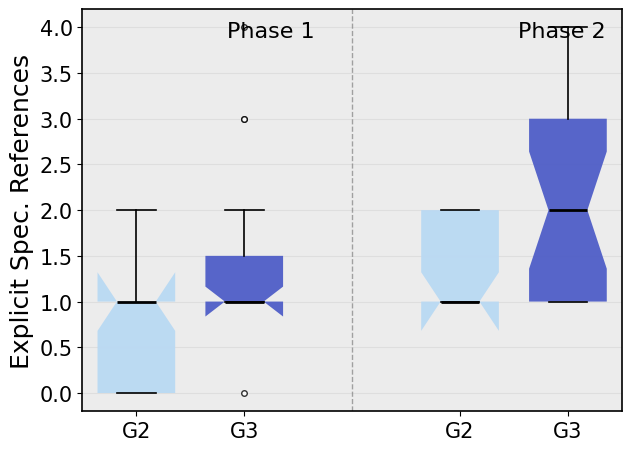

Saved: results/explicitly_referred_to_specification_styled_notched_boxplot.pdf


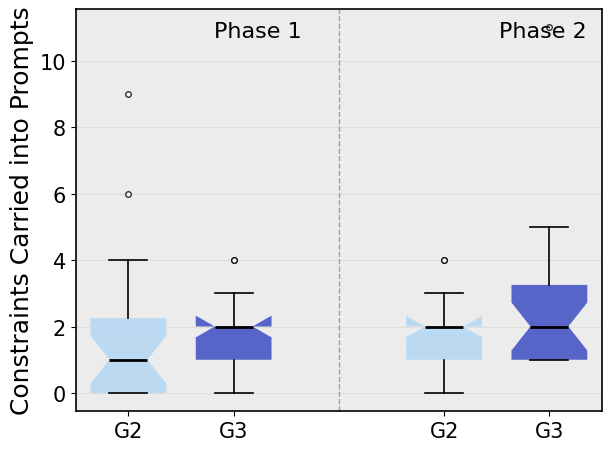

Saved: results/carried_constraints_from_spec_styled_notched_boxplot.pdf


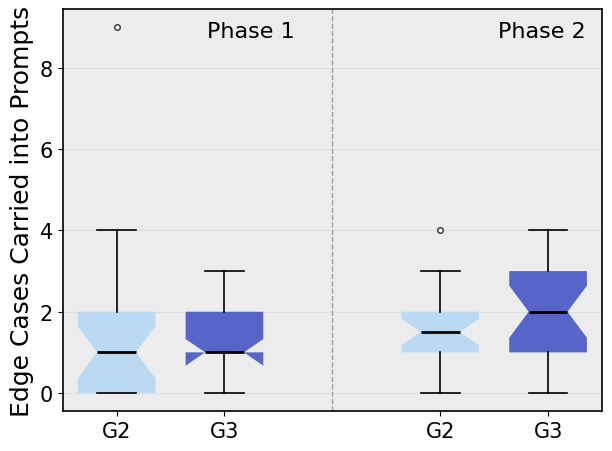

Saved: results/carried_edge_cases_from_spec_styled_notched_boxplot.pdf


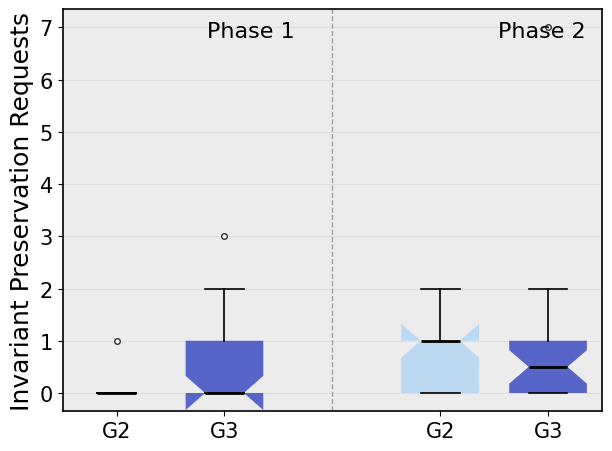

Saved: results/asked_to_preserve_invariants_styled_notched_boxplot.pdf


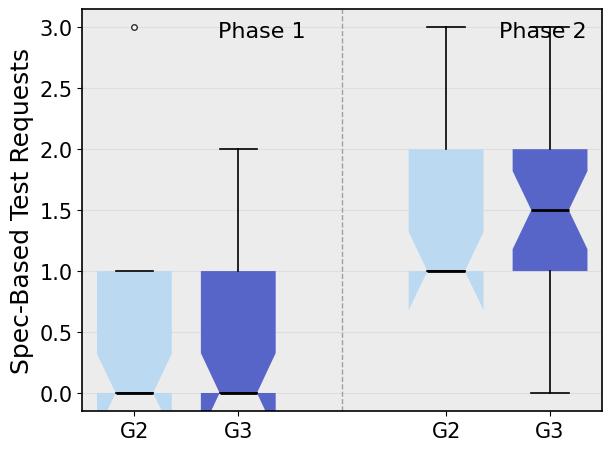

Saved: results/asked_to_update_or_generate_tests_based_on_spec_styled_notched_boxplot.pdf


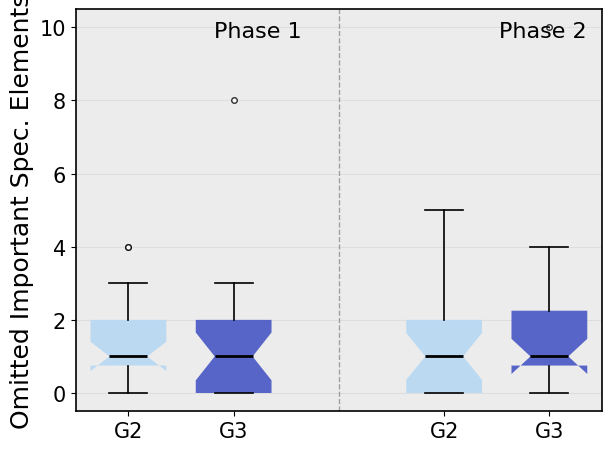

Saved: results/omitted_important_spec_elements_styled_notched_boxplot.pdf


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Find project directories
# -----------------------------
def find_project_root(start_path=None):
    """
    Search the current directory and its parents for a project
    containing either a 'Data' or 'data' directory.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        if (directory / "Data").is_dir() or (directory / "data").is_dir():
            return directory

    raise FileNotFoundError(
        f"Could not find a project containing 'Data' or 'data' "
        f"from: {start_path}"
    )


PROJECT_ROOT = find_project_root()

if (PROJECT_ROOT / "Data").is_dir():
    DATA_DIR = PROJECT_ROOT / "Data"
else:
    DATA_DIR = PROJECT_ROOT / "data"

PROMPT_DATA_DIR = DATA_DIR / "prompt_data"


# -----------------------------
# Input file paths
# -----------------------------
phase1_summary_file = (
    PROMPT_DATA_DIR
    / "Phase1_spec_alignment_summary.csv"
)

phase2_summary_file = (
    PROMPT_DATA_DIR
    / "Phase2_spec_alignment_summary.csv"
)

phase1_dataset_file = DATA_DIR / "dataset_phase1.csv"
phase2_dataset_file = DATA_DIR / "dataset_phase2.csv"


# -----------------------------
# Output directory
# -----------------------------
output_dir = Path(
   "results"
)

output_dir.mkdir(parents=True, exist_ok=True)


# Confirm that all input files exist.
input_files = [
    phase1_summary_file,
    phase2_summary_file,
    phase1_dataset_file,
    phase2_dataset_file,
]

for file_path in input_files:
    if not file_path.is_file():
        raise FileNotFoundError(
            f"Required input file not found: {file_path}"
        )


print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {output_dir}")


# -----------------------------
# Global style
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.2
})


# -----------------------------
# Load files
# -----------------------------
phase1_summary = pd.read_csv(phase1_summary_file)
phase2_summary = pd.read_csv(phase2_summary_file)

phase1_dataset = pd.read_csv(phase1_dataset_file)
phase2_dataset = pd.read_csv(phase2_dataset_file)

# -----------------------------
# Global style
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.2
})

# -----------------------------
# Standardize ID column
# -----------------------------
phase1_dataset = phase1_dataset.rename(columns={"anon_id": "id"})
phase2_dataset = phase2_dataset.rename(columns={"anon_id": "id"})

# -----------------------------
# Attach specification
# -----------------------------
if "specification" not in phase1_dataset.columns:
    raise ValueError("dataset_phase1.csv must contain a 'specification' column.")

phase1_meta = phase1_dataset[["id", "specification"]].drop_duplicates()

if "specification" in phase2_dataset.columns:
    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()
else:
    if "version" not in phase2_dataset.columns:
        raise ValueError(
            "dataset_phase2.csv needs either a 'specification' column or a 'version' column."
        )
    phase2_dataset["specification"] = (
        phase2_dataset["version"]
        .astype(str)
        .str.extract(r"(G\d+)")
    )
    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()

phase1 = phase1_summary.merge(phase1_meta, on="id", how="left")
phase2 = phase2_summary.merge(phase2_meta, on="id", how="left")

phase1["phase"] = "Phase 1"
phase2["phase"] = "Phase 2"

df = pd.concat([phase1, phase2], ignore_index=True)

# -----------------------------
# Clean specification labels
# -----------------------------
df["specification"] = df["specification"].astype(str).str.strip().str.upper()

# Keep only G2 and G3
df = df[df["specification"].isin(["G2", "G3"])].copy()

# -----------------------------
# Columns to plot
# -----------------------------
metric_cols = [
    "explicitly_referred_to_specification",
    "carried_constraints_from_spec",
    "carried_edge_cases_from_spec",
    "asked_to_preserve_invariants",
    "asked_to_update_or_generate_tests_based_on_spec",
    "omitted_important_spec_elements",
]

metric_cols = [col for col in metric_cols if col in df.columns]

print("Spec-alignment columns to plot:")
print(metric_cols)

print("\nCounts by phase/specification:")
print(df.groupby(["phase", "specification"]).size())

# -----------------------------
# Pretty y-axis labels
# -----------------------------
ylabel_map = {
    "explicitly_referred_to_specification": "Explicit Spec. References",
    "carried_constraints_from_spec": "Constraints Carried into Prompts",
    "carried_edge_cases_from_spec": "Edge Cases Carried into Prompts",
    "asked_to_preserve_invariants": "Invariant Preservation Requests",
    "asked_to_update_or_generate_tests_based_on_spec": "Spec-Based Test Requests",
    "omitted_important_spec_elements": "Omitted Important Spec. Elements",
}

# -----------------------------
# Group order
# -----------------------------
spec_order = ["G2", "G3"]
phase_order = ["Phase 1", "Phase 2"]

# positions with a gap between phases
positions = [1, 2, 4, 5]
labels = ["G2", "G3", "G2", "G3"]

# -----------------------------
# Colors
# G2 = light blue
# G3 = darker blue
# -----------------------------
light_blue = "#b9d9f3"
dark_blue = "#4f5ec7"
box_colors = [light_blue, dark_blue, light_blue, dark_blue]

# -----------------------------
# Plot one figure per metric
# -----------------------------
for col in metric_cols:
    data_to_plot = []

    for phase in phase_order:
        for spec in spec_order:
            vals = df[
                (df["phase"] == phase) &
                (df["specification"] == spec)
            ][col].dropna()

            data_to_plot.append(vals)

    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.set_facecolor("#ececec")

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.72,
        notch=True,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.0),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="none", linewidth=0),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="white",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.95)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    ax.set_ylabel(ylabel_map.get(col, col.replace("_", " ").title()))

    ax.grid(axis="y", alpha=0.22, linewidth=0.8)

    # separator between Phase 1 and Phase 2
    ax.axvline(3, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)

    # phase labels inside plot
    ax.text(
        0.43, 0.97, "Phase 1",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16
    )

    ax.text(
        0.97, 0.97, "Phase 2",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16
    )

    plt.tight_layout()

    output_path = os.path.join(
        output_dir,
        f"{col}_styled_notched_boxplot.pdf"
    )

    output_path_png = os.path.join(
        output_dir,
        f"{col}_styled_notched_boxplot.png"
    )
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")

## alignment and omission scores

In [ ]:
import pandas as pd
## this is already done in the previous steps, but we keep it here for completeness
# ============================================================
# Input files
# ============================================================
phase1_path = "Phase1_prompts_spec_align.csv"
phase2_path = "Phase2_prompts_spec_align.csv"

# ============================================================
# Label columns from original row-level CSVs
# ============================================================
LABEL_COLS = {
    "explicitly_referred_to_specification":
        "spec_label_explicitly_referred_to_specification.label",

    "carried_constraints_from_spec":
        "spec_label_carried_constraints_from_spec.label",

    "carried_edge_cases_from_spec":
        "spec_label_carried_edge_cases_from_spec.label",

    "asked_to_preserve_invariants":
        "spec_label_asked_to_preserve_invariants.label",

    "asked_to_update_or_generate_tests_based_on_spec":
        "spec_label_asked_to_update_or_generate_tests_based_on_spec.label",

    "omitted_important_spec_elements":
        "spec_label_omitted_important_spec_elements.label",
}

participant_col = "id"

# These are the categories used for participant-phase alignment score
ALIGNMENT_COLS = [
    "carried_constraints_from_spec",
    "carried_edge_cases_from_spec",
    "asked_to_preserve_invariants",
    "asked_to_update_or_generate_tests_based_on_spec",
]


# ============================================================
# Helper: normalize True/False labels
# ============================================================
def to_bool_series(s):
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .map({
             "true": True,
             "false": False,
             "1": True,
             "0": False,
             "yes": True,
             "no": False,
         })
         .fillna(False)
         .astype(bool)
    )


# ============================================================
# Summarize one phase
# ============================================================
def summarize_phase(path, phase_name):
    df = pd.read_csv(path)

    # Convert original label columns to numeric 0/1 columns
    for short_name, col in LABEL_COLS.items():
        if col not in df.columns:
            raise ValueError(f"Missing expected column: {col}")

        df[short_name] = to_bool_series(df[col]).astype(int)

    # Participant-level counts
    summary = (
        df.groupby(participant_col)
          .agg(
              total_prompts=("prompt_text", "count"),

              explicitly_referred_to_specification=(
                  "explicitly_referred_to_specification", "sum"
              ),

              carried_constraints_from_spec=(
                  "carried_constraints_from_spec", "sum"
              ),

              carried_edge_cases_from_spec=(
                  "carried_edge_cases_from_spec", "sum"
              ),

              asked_to_preserve_invariants=(
                  "asked_to_preserve_invariants", "sum"
              ),

              asked_to_update_or_generate_tests_based_on_spec=(
                  "asked_to_update_or_generate_tests_based_on_spec", "sum"
              ),

              omitted_important_spec_elements=(
                  "omitted_important_spec_elements", "sum"
              ),
          )
          .reset_index()
    )

    summary.insert(0, "phase", phase_name)

    # ========================================================
    # Participant-phase alignment score
    # ========================================================
    # appeared_at_least_once = whether this category appeared
    # in at least one prompt for this participant in this phase
    # ========================================================
    for col in ALIGNMENT_COLS:
        summary[f"{col}_appeared_at_least_once"] = summary[col] > 0

    summary["specified_element_categories_total"] = len(ALIGNMENT_COLS)

    summary["specified_element_categories_appeared"] = (
        summary[[f"{col}_appeared_at_least_once" for col in ALIGNMENT_COLS]]
        .sum(axis=1)
    )

    summary["specified_element_categories_omitted"] = (
        summary["specified_element_categories_total"]
        - summary["specified_element_categories_appeared"]
    )

    summary["alignment_score"] = (
        summary["specified_element_categories_appeared"]
        / summary["specified_element_categories_total"]
    )

    summary["omission_rate"] = (
        summary["specified_element_categories_omitted"]
        / summary["specified_element_categories_total"]
    )

    return summary


# ============================================================
# Run for both phases
# ============================================================
phase1_summary = summarize_phase(phase1_path, "Phase 1")
phase2_summary = summarize_phase(phase2_path, "Phase 2")

# ============================================================
# Save separately
# ============================================================
phase1_summary.to_csv(
    "Phase1_spec_alignment_summary.csv",
    index=False
)

phase2_summary.to_csv(
    "Phase2_spec_alignment_summary.csv",
    index=False
)

# Optional combined file
combined_summary = pd.concat(
    [phase1_summary, phase2_summary],
    ignore_index=True
)

combined_summary.to_csv(
    "Combined_spec_alignment_summary.csv",
    index=False
)

print("Saved:")
print("Phase1_spec_alignment_summary.csv")
print("Phase2_spec_alignment_summary.csv")
print("Combined_spec_alignment_summary.csv")


In [20]:
phase1_summary = pd.read_csv(phase1_output_path)
phase1_summary.head()

,phase,id,total_prompts,explicitly_referred_to_specification,carried_constraints_from_spec,carried_edge_cases_from_spec,asked_to_preserve_invariants,asked_to_update_or_generate_tests_based_on_spec,omitted_important_spec_elements,carried_constraints_from_spec_appeared_at_least_once,carried_edge_cases_from_spec_appeared_at_least_once,asked_to_preserve_invariants_appeared_at_least_once,asked_to_update_or_generate_tests_based_on_spec_appeared_at_least_once,specified_element_categories_total,specified_element_categories_appeared,specified_element_categories_omitted,alignment_score,omission_rate
0,Phase 1,S0025,2,0,0,0,0,0,0,False,False,False,False,4,0,4,0.0,1.0
1,Phase 1,S0026,1,1,1,1,0,0,0,True,True,False,False,4,2,2,0.5,0.5
2,Phase 1,S0027,4,1,0,0,0,0,1,False,False,False,False,4,0,4,0.0,1.0
3,Phase 1,S0028,5,1,1,1,0,0,2,True,True,False,False,4,2,2,0.5,0.5
4,Phase 1,S0029,6,1,1,1,0,0,1,True,True,False,False,4,2,2,0.5,0.5


Score columns to plot:
['alignment_score', 'omission_rate']

Counts by phase/specification:
phase    specification
Phase 1  G2               24
         G3               23
Phase 2  G2               24
         G3               24
dtype: int64


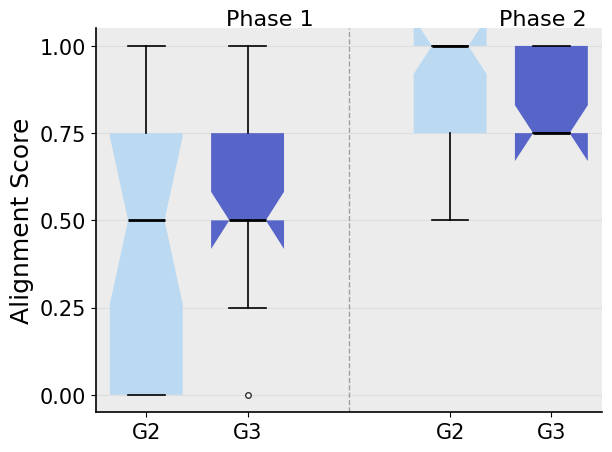

Saved: results/alignment_score_styled_notched_boxplot.pdf


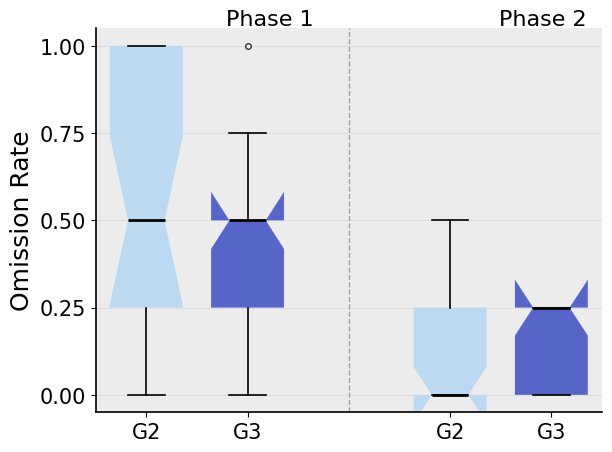

Saved: results/omission_rate_styled_notched_boxplot.pdf


In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt


phase1_summary = pd.read_csv(phase1_summary_file)
phase2_summary = pd.read_csv(phase2_summary_file)

phase1_dataset = pd.read_csv(phase1_dataset_file)
phase2_dataset = pd.read_csv(phase2_dataset_file)
# -----------------------------
# Global style
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.2
})

# -----------------------------
# Load files
# -----------------------------
phase1_summary = pd.read_csv(phase1_summary_file)
phase2_summary = pd.read_csv(phase2_summary_file)

phase1_dataset = pd.read_csv(phase1_dataset_file)
phase2_dataset = pd.read_csv(phase2_dataset_file)

# -----------------------------
# Standardize ID column
# -----------------------------
phase1_dataset = phase1_dataset.rename(columns={"anon_id": "id"})
phase2_dataset = phase2_dataset.rename(columns={"anon_id": "id"})

# -----------------------------
# Attach specification
# -----------------------------
if "specification" not in phase1_dataset.columns:
    raise ValueError("dataset_phase1.csv must contain a 'specification' column.")

phase1_meta = phase1_dataset[["id", "specification"]].drop_duplicates()

if "specification" in phase2_dataset.columns:
    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()
else:
    if "version" not in phase2_dataset.columns:
        raise ValueError(
            "dataset_phase2.csv needs either a 'specification' column or a 'version' column."
        )

    phase2_dataset["specification"] = (
        phase2_dataset["version"]
        .astype(str)
        .str.extract(r"(G\d+)")
    )

    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()

phase1 = phase1_summary.merge(phase1_meta, on="id", how="left")
phase2 = phase2_summary.merge(phase2_meta, on="id", how="left")

phase1["phase"] = "Phase 1"
phase2["phase"] = "Phase 2"

df = pd.concat([phase1, phase2], ignore_index=True)

# -----------------------------
# Clean specification labels
# -----------------------------
df["specification"] = df["specification"].astype(str).str.strip().str.upper()

# Keep only G2 and G3
df = df[df["specification"].isin(["G2", "G3"])].copy()

# -----------------------------
# Scores to plot
# -----------------------------
score_cols = [
    "alignment_score",
    "omission_rate",
]

score_cols = [col for col in score_cols if col in df.columns]

print("Score columns to plot:")
print(score_cols)

print("\nCounts by phase/specification:")
print(df.groupby(["phase", "specification"]).size())

# -----------------------------
# Pretty y-axis labels
# -----------------------------
ylabel_map = {
    "alignment_score": "Alignment Score",
    "omission_rate": "Omission Rate",
}

# -----------------------------
# Group order
# -----------------------------
spec_order = ["G2", "G3"]
phase_order = ["Phase 1", "Phase 2"]

# positions with a gap between phases
positions = [1, 2, 4, 5]
labels = ["G2", "G3", "G2", "G3"]

# -----------------------------
# Colors
# G2 = light blue
# G3 = darker blue
# -----------------------------
light_blue = "#b9d9f3"
dark_blue = "#4f5ec7"
box_colors = [light_blue, dark_blue, light_blue, dark_blue]

# -----------------------------
# Plot one figure per score
# -----------------------------
for col in score_cols:
    data_to_plot = []

    for phase in phase_order:
        for spec in spec_order:
            vals = df[
                (df["phase"] == phase) &
                (df["specification"] == spec)
            ][col].dropna()

            data_to_plot.append(vals)

    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.set_facecolor("#ececec")

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.72,
        notch=True,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.0),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="none", linewidth=0),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="white",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    # Fill box colors
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.95)

    # X-axis labels
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    # Y-axis label
    ax.set_ylabel(ylabel_map.get(col, col.replace("_", " ").title()))

    # Scores are proportions, so force 0-1 range
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

    # Subtle grid
    ax.grid(axis="y", alpha=0.22, linewidth=0.8)

    # Separator between Phase 1 and Phase 2
    ax.axvline(3, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)

    # Phase labels inside the plot
    ax.text(
        0.43, 1.05, "Phase 1",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16
    )

    ax.text(
        0.97, 1.05, "Phase 2",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16
    )

    # Clean style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    output_path = os.path.join(
        output_dir,
        f"{col}_styled_notched_boxplot.pdf"
    )
    output_path_png = os.path.join(
        output_dir,
        f"{col}_styled_notched_boxplot.png"
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")